In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [44]:
input_video = r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Input Video\solidWhiteRight.mp4"
output_video = r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Output.mp4"

**1. LANE DETECTION MODULE**

In [47]:
#Edge detection
def canny(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    return edges

In [49]:
#Region of Interest
def region_of_interest(image):
    height = image.shape[0]
    polygon = np.array([[(0, height), (960, height), (480, 260)]])
    mask = np.zeros_like(image)
    cv2.fillPoly(mask, polygon, 255)
    return cv2.bitwise_and(image, mask)

In [51]:
#Lane Line Construction Functions
def make_coordinates(image, params):
    slope, intercept = params
    y1 = image.shape[0]
    y2 = int(y1 * 0.6)
    x1 = int((y1 - intercept) / (slope + 1e-6))
    x2 = int((y2 - intercept) / (slope + 1e-6))
    return np.array([x1, y1, x2, y2])

def average_slope_intercept(image, lines):
    if lines is None:
        return None

    left, right = [], []

    for line in lines:
        x1, y1, x2, y2 = line[0]
        slope = (y2 - y1) / (x2 - x1 + 1e-6)
        intercept = y1 - slope * x1

        if slope < 0:
            left.append((slope, intercept))
        else:
            right.append((slope, intercept))

    output = []
    for group in [left, right]:
        if len(group):
            avg = np.mean(group, axis=0)
            output.append(make_coordinates(image, avg))

    return output

In [53]:
#Draw Lane Lines
def display_lines(image, lines):
    line_img = np.zeros_like(image)
    if lines is not None:
        for x1,y1,x2,y2 in lines:
            cv2.line(line_img, (x1,y1), (x2,y2), (0,255,0), 10)
    return line_img

In [55]:
#Lane Pipeline
def lane_pipeline(image):
    edges = canny(image)
    cropped = region_of_interest(edges)
    lines = cv2.HoughLinesP(cropped, 1, np.pi/180, 60, minLineLength=40, maxLineGap=50)
    averaged = average_slope_intercept(image, lines)
    line_img = display_lines(image, averaged)
    return cv2.addWeighted(image, 0.8, line_img, 1, 1)

In [57]:
#Steering Angle
def compute_steering_angle(image):
    return 0  

**2. OBJECT DETECTION MODULE (SSD MobileNet)**

In [60]:
#Load Labels + Model
classFile = r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Models\coco.names"
with open(classFile) as f:
    classNames = f.read().rstrip("\n").split("\n")

net = cv2.dnn_DetectionModel(
    r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Models\frozen_inference_graph.pb", 
    r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Models\ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt")

net.setInputSize(320, 320)
net.setInputScale(1/127.5)
net.setInputMean((127.5,127.5,127.5))
net.setInputSwapRB(True)

< cv2.dnn.Model 0000029065099C10>

In [62]:
#Detect Vehicles
def detect_objects(image, conf=0.55):
    classIds, confs, boxes = net.detect(image, confThreshold=conf)
    objs = []

    if len(classIds) != 0:
        for classId, confidence, box in zip(classIds.flatten(), confs.flatten(), boxes):
            label = classNames[classId-1]
            if label not in ["car", "bus", "truck", "motorbike"]:
                continue
            objs.append((label, float(confidence), box))

    return objs

In [64]:
#Draw the Detected Objects
def draw_objects(image, objects):
    for label, conf, box in objects:
        x,y,w,h = box
        cv2.rectangle(image,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(image,f"{label} {int(conf*100)}%",(x,y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)
    return image

**3. CONTROL SIMULATION MODULE(BRAKING + TRAFFIC LIGHT)**

In [67]:
#Traffic Light Detection (Color-Based)
def detect_traffic_light(frame):
    h, w, _ = frame.shape

    roi = frame[0:int(h*0.35), int(w*0.3):int(w*0.7)]

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    red_mask = cv2.inRange(hsv, (0,120,70), (10,255,255)) + \
               cv2.inRange(hsv, (170,120,70), (180,255,255))

    yellow_mask = cv2.inRange(hsv, (15,150,150), (35,255,255))
    green_mask  = cv2.inRange(hsv, (40,120,120), (90,255,255))

    red_pixels    = cv2.countNonZero(red_mask)
    yellow_pixels = cv2.countNonZero(yellow_mask)
    green_pixels  = cv2.countNonZero(green_mask)

    #Higher threshold
    THRESH = 3000

    if red_pixels > THRESH:
        return "RED"
    elif yellow_pixels > THRESH:
        return "YELLOW"
    elif green_pixels > THRESH:
        return "GREEN"
    else:
        return "NONE"

In [69]:
#Control Decision (Speed + Braking + Steering)
def control_system(steering, objects, tl):
    speed = 30
    action = "Go Straight"

    if tl == "RED":
        return steering, 0, "STOP - RED LIGHT"

    if tl == "YELLOW":
        return steering, 10, "Slow Down - Yellow"

    # Object handling
    for label, conf, box in objects:
        x,y,w,h = box
        area = w*h

        if area > 6500:
            return steering, 0, "BRAKE! Obstacle Close"

        if area > 3500:
            return steering, 15, "Slow - Vehicle Ahead"

    if steering < -10: action = "Turn LEFT"
    elif steering > 10: action = "Turn RIGHT"

    return steering, speed, action

In [71]:
#IMAGE PROCESSING PIPELINE
def process_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Image not found")
        return

    img = cv2.resize(img, (960,540))

    lane_img = lane_pipeline(img)
    steering = compute_steering_angle(img)
    objects = detect_objects(img)
    traffic = detect_traffic_light(img)

    steer, speed, action = control_system(steering, objects, traffic)

    result = draw_objects(lane_img, objects)

    cv2.putText(result,f"Steering:{steer}",(10,30),
                cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),2)
    cv2.putText(result,f"Speed:{speed}",(10,70),
                cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,255,0),2)
    cv2.putText(result,f"Action:{action}",(10,110),
                cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,255,255),2)
    cv2.putText(result,f"Traffic:{traffic}",(700,40),
                cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,0,255),2)

    return result

In [73]:
#VIDEO PROCESSING PIPELINE
def process_video(input_video, output_video):
    cap = cv2.VideoCapture(input_video)
    if not cap.isOpened():
        print(" Cannot open video")
        return

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_video, fourcc, 20, (960,540))

    while True:
        ret, frame = cap.read()
        if not ret: break

        frame = cv2.resize(frame, (960,540))

        lane_img = lane_pipeline(frame)
        steering = compute_steering_angle(frame)
        objects = detect_objects(frame)
        traffic = detect_traffic_light(frame)

        steer, speed, action = control_system(steering, objects, traffic)

        frame_out = draw_objects(lane_img, objects)

        cv2.putText(frame_out,f"Steering:{steer}",(10,30),
                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),2)
        cv2.putText(frame_out,f"Speed:{speed}",(10,70),
                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,255,0),2)
        cv2.putText(frame_out,f"Action:{action}",(10,110),
                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,255,255),2)
        cv2.putText(frame_out,f"Traffic:{traffic}",(700,40),
                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,0,255),2)

        out.write(frame_out)

    cap.release()
    out.release()
    print("VIDEO SAVED:", output_video)

(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

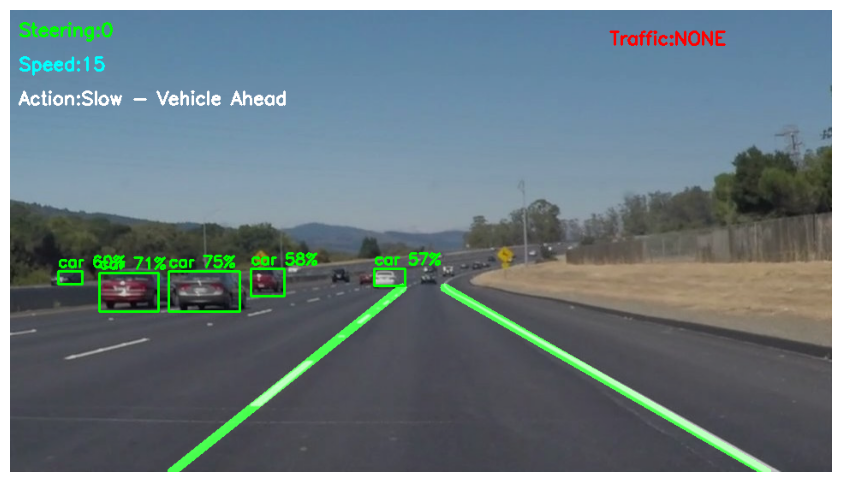

In [75]:
#Image Run
img_result = process_image(r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Input Images\solidWhiteCurve.jpg")
cv2.imwrite("final_image_output.jpg", img_result)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [79]:
#Video Run
process_video(
   r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Input Video\solidWhiteRight.mp4",
    r"C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Output.mp4")

VIDEO SAVED: C:\Users\Jahnavi\Desktop\Internship_3 Sem\AI Self Driving Car\Output.mp4
